# Gaussian Drift OPT Debug

Minimal notebook for testing only the homogeneous Gaussian initial-condition drift. FD is the control; OPT is the object under test. Shared helpers live in `temporaryHelpers.jl`.

## 1. Setup

In [1]:
using Pkg
cd(@__DIR__)
Pkg.activate("../")

try
    using Metal
catch err
    @warn "Metal not loaded; continuing on CPU" err
end
ParamFile = "../config/testparam.csv"

include("../src/batchFiles/batchGPU.jl")
include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")
using .commonBatchs, .planet1D, .GeoPoints

include("../src/flexOPT.jl")
using .flexOPT

include("temporaryHelpers.jl")


devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

  Activating project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


build_toy_opt_prepared (generic function with 1 method)

## 2. Controls And Initial Gaussian

In [2]:
# Homogeneous toy controls
shape = (201, 201)
velocity_value = 2600.0
dx = 100.0
cfl = 0.45
Nt = 180
store_every = 3
sigma = 10.0
amplitude = 1.0

# OPT controls
pointsInSpace = 3
pointsInTime = 3
supplementaryOrder = 2
orderBspace = 1
orderBtime = 1

center = CartesianIndex(cld(shape[1], 2), cld(shape[2], 2))
dt = cfl * dx / velocity_value
delta = (dx, dx, dt)
velocity = fill(velocity_value, shape)
init_gaussian = gaussian_field(shape, center; sigma=sigma, amplitude=amplitude)

@show shape center velocity_value delta sigma Nt store_every


shape = (201, 201)
center = CartesianIndex(101, 101)
velocity_value = 2600.0
delta = (100.0, 100.0, 0.01730769230769231)
sigma = 10.0
Nt = 180
store_every = 3


3

## 3. FD Baseline

In [3]:
preparedFD = prepare_fd2d_acoustic_baseline(velocity, delta)
frames_fd = propagate_linear_frames_from_initial(
    preparedFD,
    init_gaussian,
    init_gaussian,
    Nt;
    store_every=store_every,
    blowup_limit=1e12,
)

fd_report = wavefield_snapshot_report(frames_fd)
fd_drift = drift_report(frames_fd, center)
fd_argmax = argmax_report(frames_fd, center)
fd_symmetry = symmetry_report(frames_fd, center)

@show length(frames_fd) fd_report[1] fd_report[end]
@show fd_drift[1] fd_drift[end]
@show fd_argmax[1] fd_argmax[end]
@show fd_symmetry[1] fd_symmetry[end]


length(frames_fd) = 61
fd_report[1] = (frame = 1, nbad = 0, finite_max = 1.0, minimum = 3.720075976020836e-44, maximum = 1.0)
fd_report[end] = (frame = 61, nbad = 0, finite_max = 0.12650212646124115, minimum = -0.07299382461789063, maximum = 0.12650212646124115)
fd_drift[1] = (frame = 1, cm_x = 100.99999999999979, cm_z = 101.00000000000017, drift_x = -2.1316282072803006e-13, drift_z = 1.7053025658242404e-13, maxabs = 1.0)
fd_drift[end] = (frame = 61, cm_x = 101.00000000000011, cm_z = 100.99999999999959, drift_x = 1.1368683772161603e-13, drift_z = -4.121147867408581e-13, maxabs = 0.12650212646124115)
fd_argmax[1] = (frame = 1, maxpoint = CartesianIndex(101, 101), dx = 0, dz = 0, value = 1.0, maxabs = 1.0)
fd_argmax[end] = (frame = 61, maxpoint = CartesianIndex(43, 165), dx = -58, dz = 64, value = 0.12650212646124115, maxabs = 0.12650212646124115)
fd_symmetry[1] = (frame = 1, lr = 0.0, ud = 0.0, diag = 0.0)
fd_symmetry[end] = (frame = 61, lr = 1.1842581322338107e-15, ud = 1.3256361873321

(frame = 61, lr = 1.1842581322338107e-15, ud = 1.325636187332138e-15, diag = 1.412088476802089e-15)

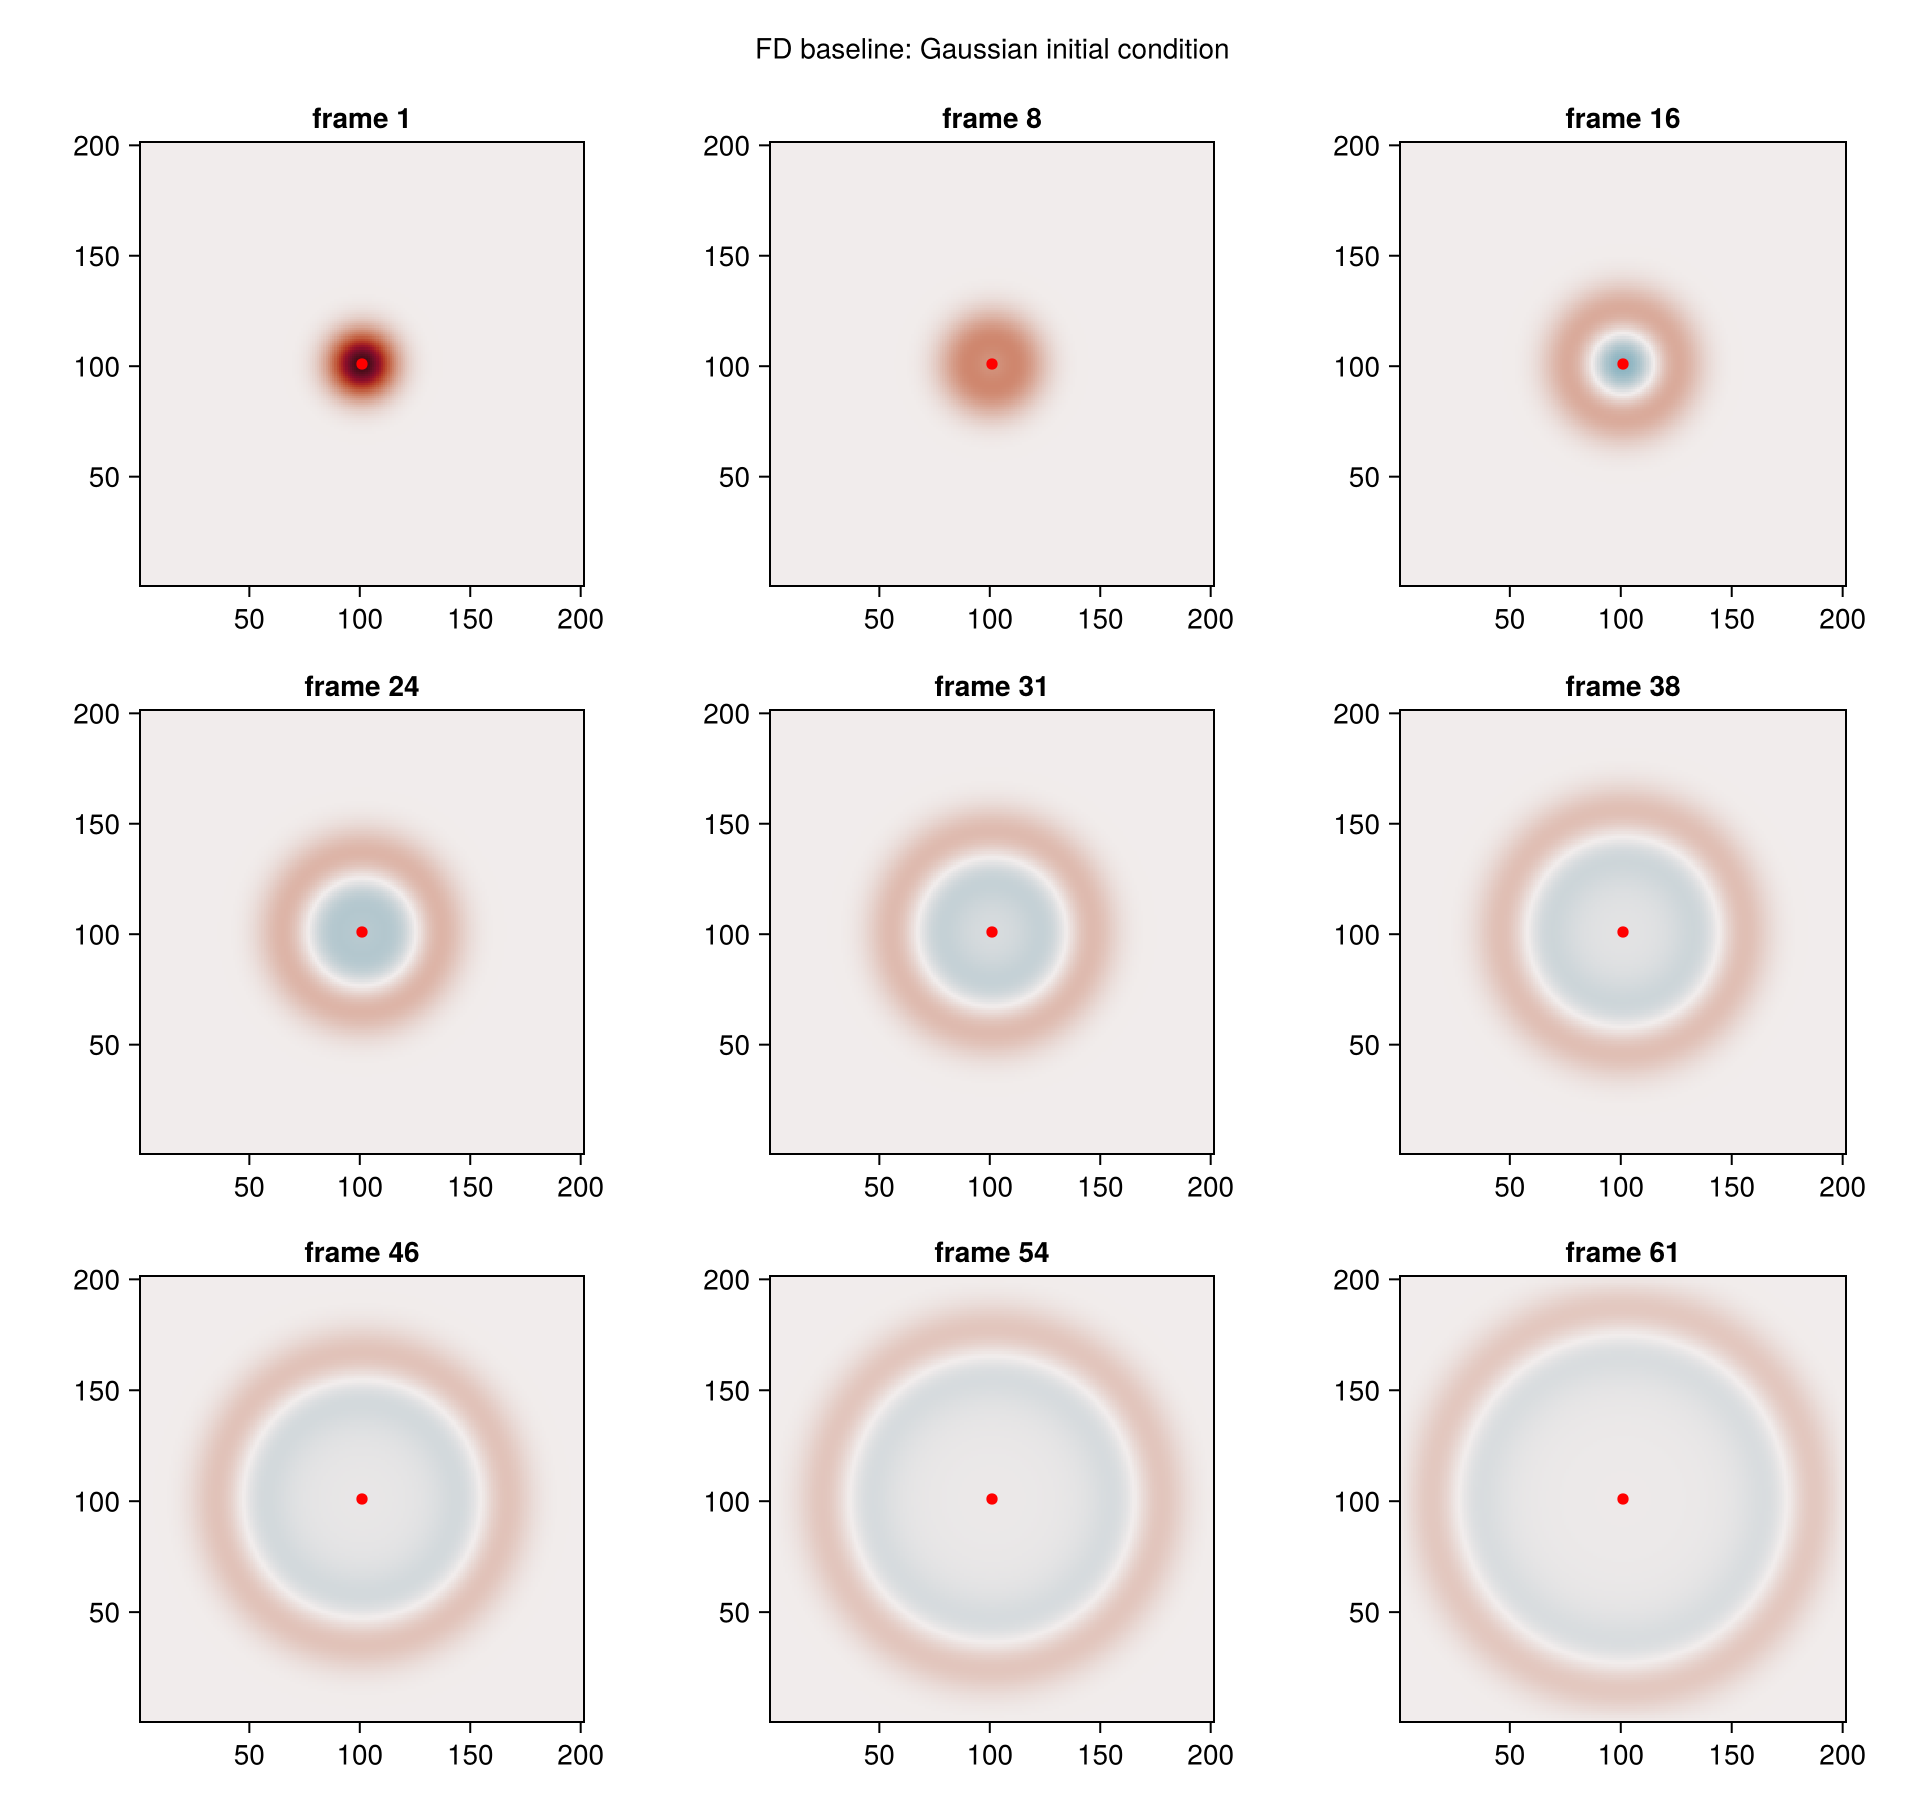

In [4]:
fig_fd = plot_wave_snapshots(
    frames_fd;
    sourcePoint=center,
    title="FD baseline: Gaussian initial condition",
)
fig_fd


## 4. OPT Build

In [5]:
toyOPT = build_toy_opt_prepared(
    velocity_value=velocity_value,
    shape=shape,
    dx=dx,
    cfl=cfl,
    pointsInSpace=pointsInSpace,
    pointsInTime=pointsInTime,
    supplementaryOrder=supplementaryOrder,
    orderBspace=orderBspace,
    orderBtime=orderBtime,
)
preparedOPT = toyOPT.prepared

@show preparedOPT.spaceShape preparedOPT.NpointsSpace preparedOPT.NField preparedOPT.NForceField preparedOPT.timePointsUsedForOneStep
@show size(preparedOPT.A_unknown) nnz(preparedOPT.A_unknown) nnz(preparedOPT.L_known)

opt_A_report = implicit_matrix_report(preparedOPT)
@show opt_A_report


(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})

(size = (40401, 40401), nnz = 361201, zero_rows = 0, diag_min = 92805.5613286294, diag_median = 92805.5613286294, diag_max = 92805.5613286294, row_abs_min = 106076.39250855154, row_abs_max = 134875.0072585577)

## 5. OPT Propagation

In [6]:
frames_opt = propagate_linear_frames_from_initial(
    preparedOPT,
    init_gaussian,
    init_gaussian,
    Nt;
    store_every=store_every,
    blowup_limit=1e12,
)

opt_report = wavefield_snapshot_report(frames_opt)
opt_drift = drift_report(frames_opt, center)
opt_argmax = argmax_report(frames_opt, center)
opt_symmetry = symmetry_report(frames_opt, center)

@show length(frames_opt) opt_report[1] opt_report[end]
@show opt_drift[1] opt_drift[end]
@show opt_argmax[1] opt_argmax[end]
@show opt_symmetry[1] opt_symmetry[end]


length(frames_opt) = 61
opt_report[1] = (frame = 1, nbad = 0, finite_max = 1.0, minimum = 3.720075976020836e-44, maximum = 1.0)
opt_report[end] = (frame = 61, nbad = 0, finite_max = 0.6989461062444882, minimum = 1.0252738373634858e-54, maximum = 0.6989461062444882)
opt_drift[1] = (frame = 1, cm_x = 100.99999999999979, cm_z = 101.00000000000017, drift_x = -2.1316282072803006e-13, drift_z = 1.7053025658242404e-13, maxabs = 1.0)
opt_drift[end] = (frame = 61, cm_x = 64.5363930538154, cm_z = 64.53638156131741, drift_x = -36.4636069461846, drift_z = -36.46361843868259, maxabs = 0.6989461062444882)
opt_argmax[1] = (frame = 1, maxpoint = CartesianIndex(101, 101), dx = 0, dz = 0, value = 1.0, maxabs = 1.0)
opt_argmax[end] = (frame = 61, maxpoint = CartesianIndex(65, 64), dx = -36, dz = -37, value = 0.6989461062444882, maxabs = 0.6989461062444882)
opt_symmetry[1] = (frame = 1, lr = 0.0, ud = 0.0, diag = 0.0)
opt_symmetry[end] = (frame = 61, lr = 0.9970251891579625, ud = 0.9970251985014121, diag 

(frame = 61, lr = 0.9970251891579625, ud = 0.9970251985014121, diag = 0.9999951576831331)

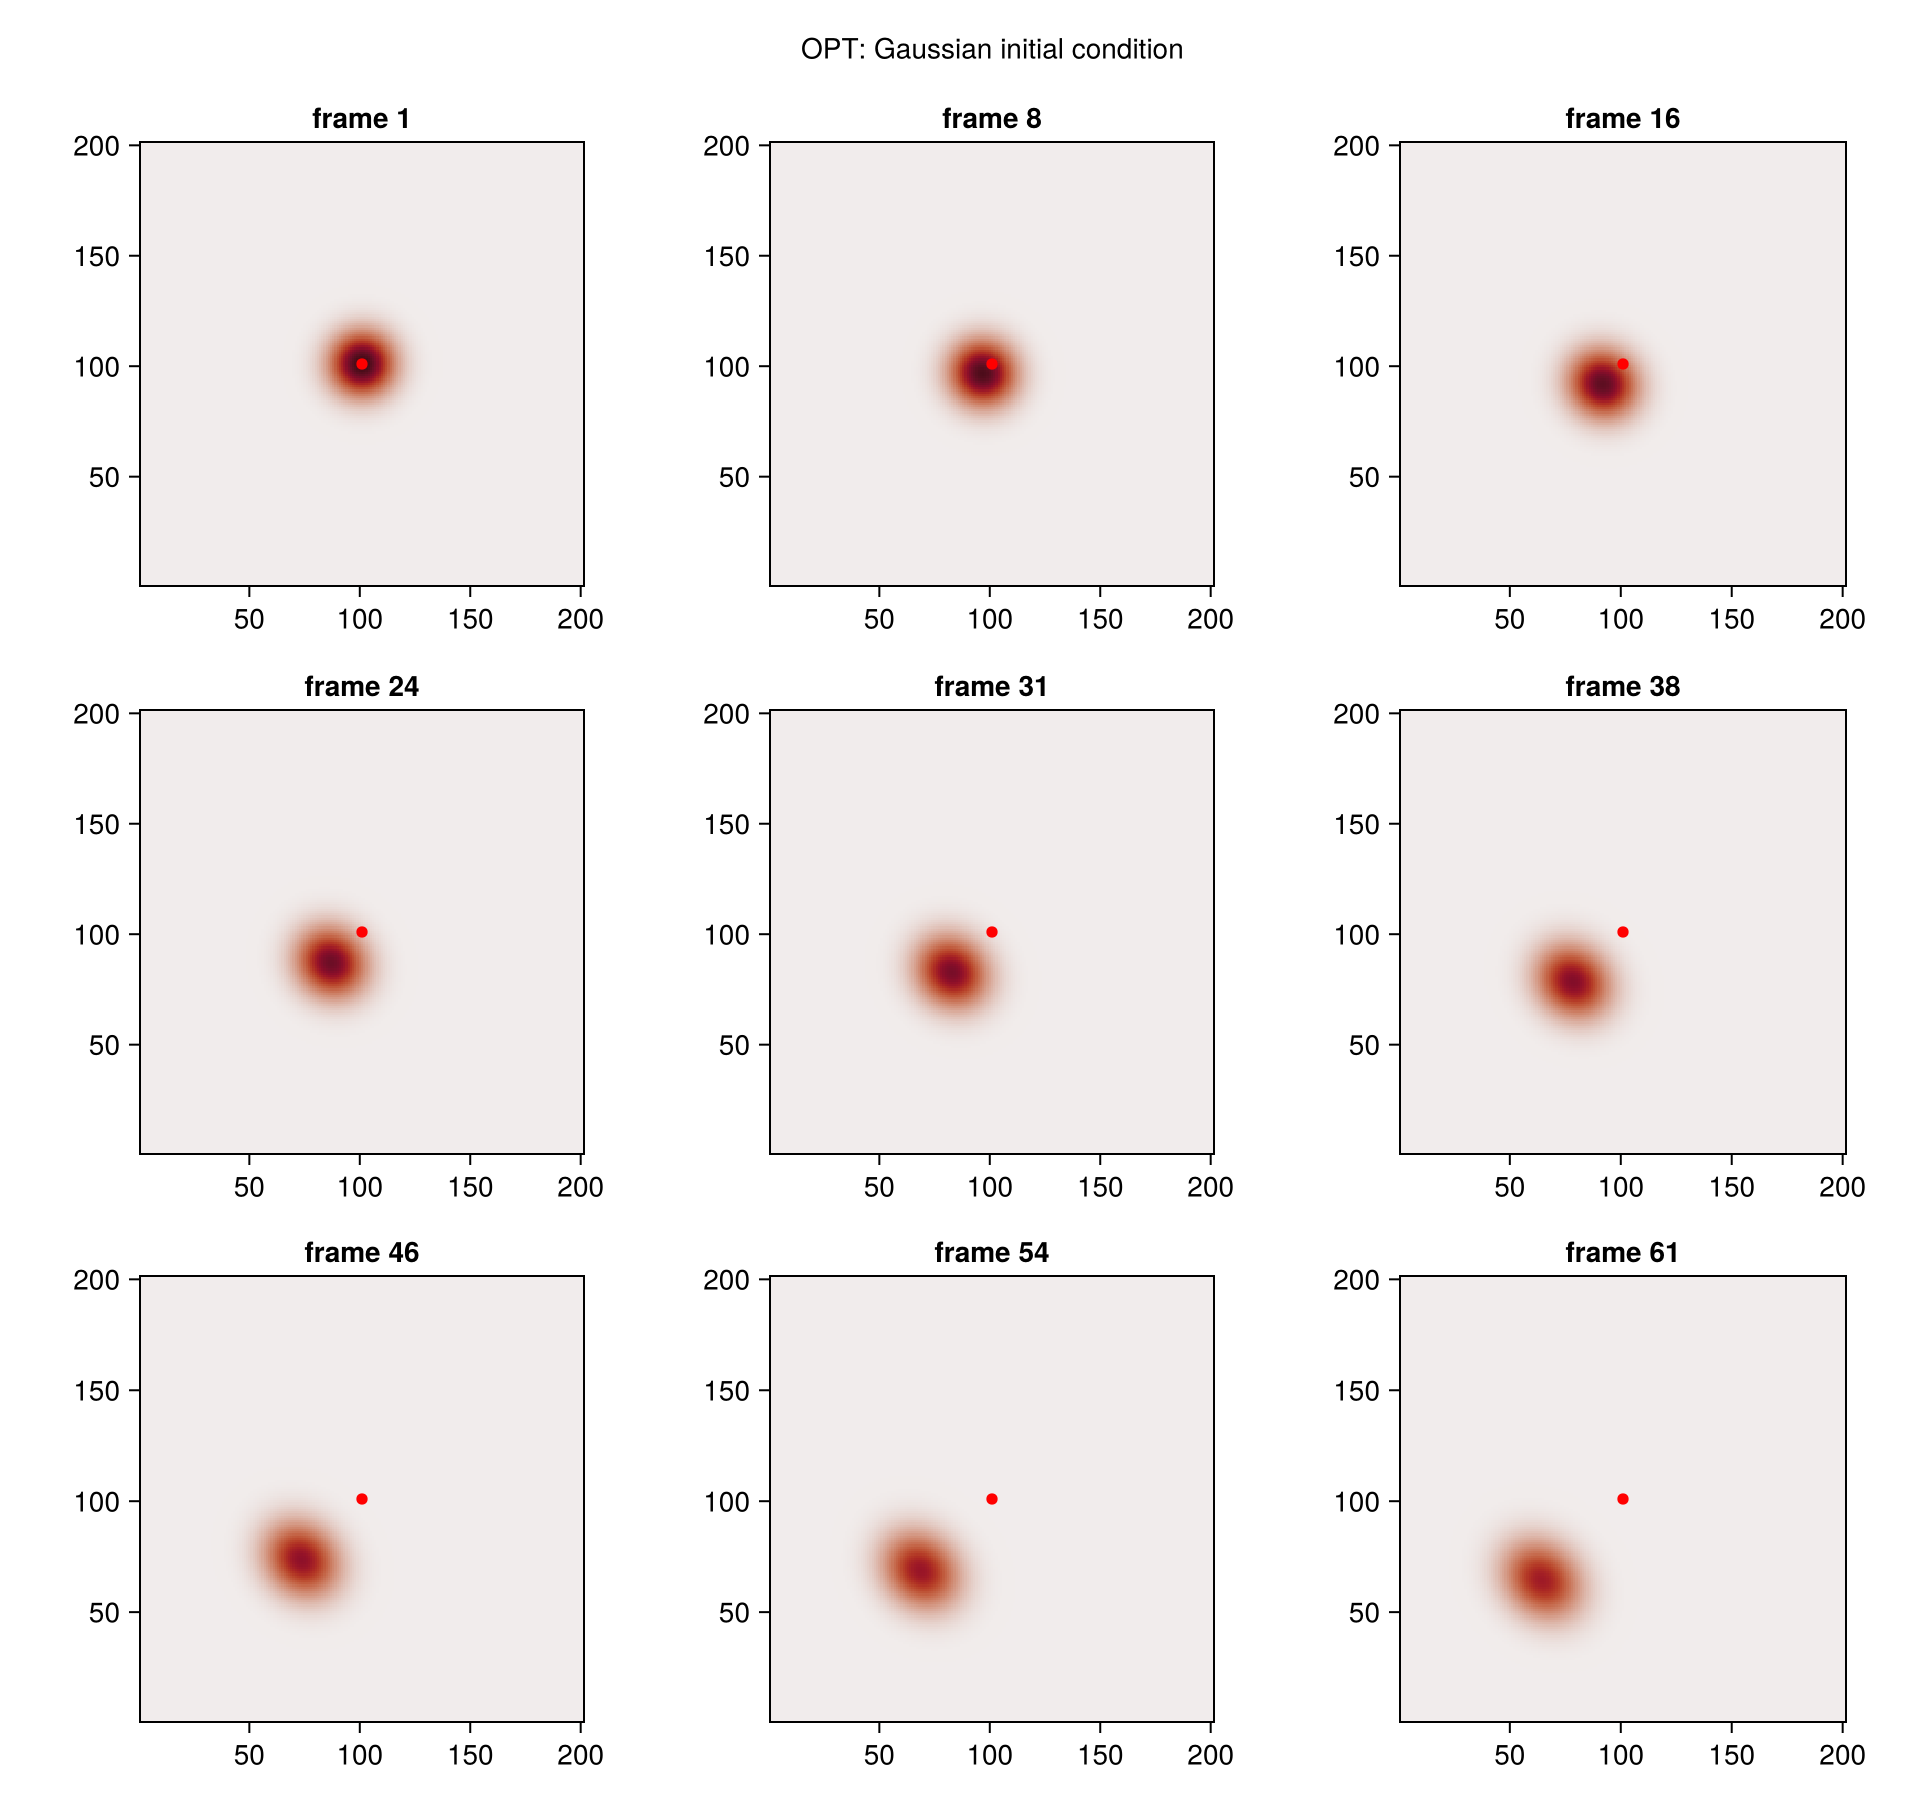

In [7]:
fig_opt = plot_wave_snapshots(
    frames_opt;
    sourcePoint=center,
    title="OPT: Gaussian initial condition",
)
fig_opt


## 6. FD vs OPT Drift Comparison

In [8]:
drift_comparison = (
    fd_final_drift = fd_drift[end],
    opt_final_drift = opt_drift[end],
    fd_final_argmax = fd_argmax[end],
    opt_final_argmax = opt_argmax[end],
    fd_final_symmetry = fd_symmetry[end],
    opt_final_symmetry = opt_symmetry[end],
)
drift_comparison


(fd_final_drift = (frame = 61, cm_x = 101.00000000000011, cm_z = 100.99999999999959, drift_x = 1.1368683772161603e-13, drift_z = -4.121147867408581e-13, maxabs = 0.12650212646124115), opt_final_drift = (frame = 61, cm_x = 64.5363930538154, cm_z = 64.53638156131741, drift_x = -36.4636069461846, drift_z = -36.46361843868259, maxabs = 0.6989461062444882), fd_final_argmax = (frame = 61, maxpoint = CartesianIndex(43, 165), dx = -58, dz = 64, value = 0.12650212646124115, maxabs = 0.12650212646124115), opt_final_argmax = (frame = 61, maxpoint = CartesianIndex(65, 64), dx = -36, dz = -37, value = 0.6989461062444882, maxabs = 0.6989461062444882), fd_final_symmetry = (frame = 61, lr = 1.1842581322338107e-15, ud = 1.325636187332138e-15, diag = 1.412088476802089e-15), opt_final_symmetry = (frame = 61, lr = 0.9970251891579625, ud = 0.9970251985014121, diag = 0.9999951576831331))

## 7. Optional OPT Parameter Sweep

In [9]:
# Optional: change these values and rerun to see whether drift is caused by OPT parameters.
# Some implicit OPT future blocks can be singular; those cases are reported and skipped.
parameter_cases = [(3,2), (3,0), (5,2)]

sweep_rows = NamedTuple[]
for (pspace, supp) in parameter_cases
    println("building OPT case pointsInSpace=$pspace supplementaryOrder=$supp")
    try
        toy = build_toy_opt_prepared(
            velocity_value=velocity_value,
            shape=shape,
            dx=dx,
            cfl=cfl,
            pointsInSpace=pspace,
            pointsInTime=pointsInTime,
            supplementaryOrder=supp,
            orderBspace=orderBspace,
            orderBtime=orderBtime,
        )
        a_report = implicit_matrix_report(toy.prepared)
        fr = propagate_linear_frames_from_initial(toy.prepared, init_gaussian, init_gaussian, Nt; store_every=store_every, blowup_limit=1e12)
        dr = drift_report(fr, center)
        sy = symmetry_report(fr, center)
        push!(sweep_rows, (
            pointsInSpace=pspace,
            supplementaryOrder=supp,
            status=:ok,
            matrix_report=a_report,
            nframes=length(fr),
            final_drift=dr[end],
            final_symmetry=sy[end],
            final_max=maximum(abs, fr[end]),
        ))
    catch err
        push!(sweep_rows, (
            pointsInSpace=pspace,
            supplementaryOrder=supp,
            status=Symbol(nameof(typeof(err))),
            matrix_report=nothing,
            nframes=0,
            final_drift=nothing,
            final_symmetry=nothing,
            final_max=NaN,
        ))
        @warn "Skipping failed OPT case" pointsInSpace=pspace supplementaryOrder=supp exception=(err, catch_backtrace())
    end
end
sweep_rows


building OPT case pointsInSpace=3 supplementaryOrder=2
(vars, iVars) = (v(x, y), 1)
(vars, iVars) = (v(x, y), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Floa

┌ Error: A_unknown factorization failed
│   exception = (SingularException(0), Union{Ptr{Nothing}, Base.InterpreterIP}[Ptr{Nothing}(0x000000034bd133d7), Ptr{Nothing}(0x000000034bd08297), Ptr{Nothing}(0x000000034bd087e3), Ptr{Nothing}(0x000000034be14c2f), Ptr{Nothing}(0x0000000105c3302b), Ptr{Nothing}(0x0000000105c32e0f), Ptr{Nothing}(0x0000000105c3406b), Ptr{Nothing}(0x0000000119f5686b), Ptr{Nothing}(0x0000000111954247), Ptr{Nothing}(0x0000000105c04c73), Ptr{Nothing}(0x0000000111944513), Ptr{Nothing}(0x000000011190c31f), Ptr{Nothing}(0x000000011191c10f), Ptr{Nothing}(0x000000011191c1d3), Ptr{Nothing}(0x000000012c46c837), Ptr{Nothing}(0x000000012c46cbdf), Ptr{Nothing}(0x00000001116652b3), Ptr{Nothing}(0x000000011168405f), Ptr{Nothing}(0x0000000111684123), Ptr{Nothing}(0x00000001114ccd77), Ptr{Nothing}(0x0000000105c3302b), Ptr{Nothing}(0x0000000105c32e0f), Ptr{Nothing}(0x0000000105c3406b), Ptr{Nothing}(0x0000000119f5686b), Ptr{Nothing}(0x000000011b205f0f), Ptr{Nothing}(0x000000011abc290f

3-element Vector{NamedTuple}:
 (pointsInSpace = 3, supplementaryOrder = 2, status = :ok, matrix_report = (size = (40401, 40401), nnz = 361201, zero_rows = 0, diag_min = 92805.5613286294, diag_median = 92805.5613286294, diag_max = 92805.5613286294, row_abs_min = 106076.39250855154, row_abs_max = 134875.0072585577), nframes = 61, final_drift = (frame = 61, cm_x = 64.5363930538154, cm_z = 64.53638156131741, drift_x = -36.4636069461846, drift_z = -36.46361843868259, maxabs = 0.6989461062444882), final_symmetry = (frame = 61, lr = 0.9970251891579625, ud = 0.9970251985014121, diag = 0.9999951576831331), final_max = 0.6989461062444882)
 (pointsInSpace = 3, supplementaryOrder = 0, status = :ok, matrix_report = (size = (40401, 40401), nnz = 361201, zero_rows = 0, diag_min = 62341.811589122866, diag_median = 62341.811589122866, diag_max = 62341.811589122866, row_abs_min = 80796.09265302987, row_abs_max = 115364.96203443906), nframes = 61, final_drift = (frame = 61, cm_x = 92.6697228282376, cm_z 